In [ ]:
import torch; import sklearn; from torch import nn

# 1. Carregar dados
iris = sklearn.datasets.load_iris()
X = iris.data        # 4 features: sépalas e pétalas
y = (iris.target == 1).astype(float)  # 1 se Versicolor, 0 caso contrário

# 2. Preparar dados para pytorch
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [ ]:
from sklearn.model_selection import train_test_split
seed = 21 # com a semente padrão a Rede Neural atingi facilmente 100% de acuracia e precisão devido a distribuição dos dados 0 e 1 nos conjuntos de teste e treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [ ]:
# 3. Definir modelo
import torch.nn.functional as F
class RedeNeural(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RedeNeural, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Criar modelo
modelo = RedeNeural(4, 16, 1)  # 4 features → 1 saída (probabilidade de ser Versicolor)

import copy
modelo_clonado = copy.deepcopy(modelo)

learning_rate = 0.1

# Definir função de perda e algoritmo de otimização
funcao_perda = torch.nn.BCEWithLogitsLoss()  # combinação de sigmoid + BCE
optimizer = torch.optim.SGD(modelo.parameters(), lr=learning_rate)

In [ ]:
# Loop de treino
epochs = 700 # Com muitas epocas a rede neural atinge facilmente 100% de acuracia e precisão devido a simplicidade do dataset
for epoch in range(epochs):
    optimizer.zero_grad()           # Limpa gradientes
    outputs = modelo(X_train)             # Forward
    loss = funcao_perda(outputs, y_train) # Calcula perda
    loss.backward()                 # Calcula derivadas do gradiente
    optimizer.step()                # Aplica regra de alteração dos parâmetros

    if (epoch + 1) % 100 == 0:
        print(f"Época [{epoch+1}/100], Loss: {loss.item():.4f}")
# loss na epoca 100 com 8 neuronios = 0.4967
# loss na epoca 100 com 16 neuronios = 0.4541

Época [100/100], Loss: 0.4541
Época [200/100], Loss: 0.3227
Época [300/100], Loss: 0.2293
Época [400/100], Loss: 0.1505
Época [500/100], Loss: 0.1104
Época [600/100], Loss: 0.0830
Época [700/100], Loss: 0.0756


In [ ]:
with torch.no_grad():  # Desabilita o cálculo de gradientes, economizando RAM e tempo de processamento
    y_nn = modelo(X_test)

# 3. reduz o intervalo dos resultados do teste
y_pred_probs = torch.sigmoid(y_nn)

# 4. Converter tensores do PyTorch para arrays NumPy para a utilização do scikit-learn
y_test_np = y_test.numpy()
y_pred_probs_np = y_pred_probs.numpy()
threshold = 0.5
y_pred_classes = (y_pred_probs_np >= threshold).astype(int)

Acurácia: 0.9667
Precisão: 1.0000

Matriz de Confusão:
[[18  0]
 [ 1 11]]


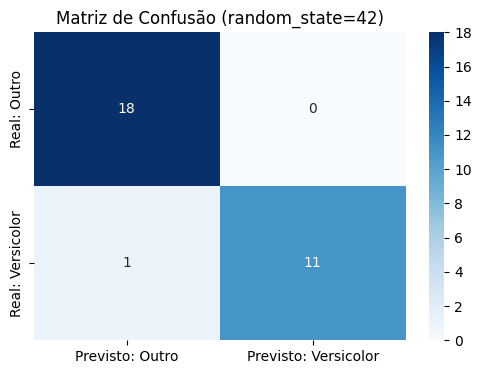

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular métricas
acc = accuracy_score(y_test_np, y_pred_classes)
prec = precision_score(y_test_np, y_pred_classes)
cm = confusion_matrix(y_test_np, y_pred_classes)

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")

# Visualização
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Outro', 'Previsto: Versicolor'],
            yticklabels=['Real: Outro', 'Real: Versicolor'])
plt.title('Matriz de Confusão (random_state=21)')
plt.show()

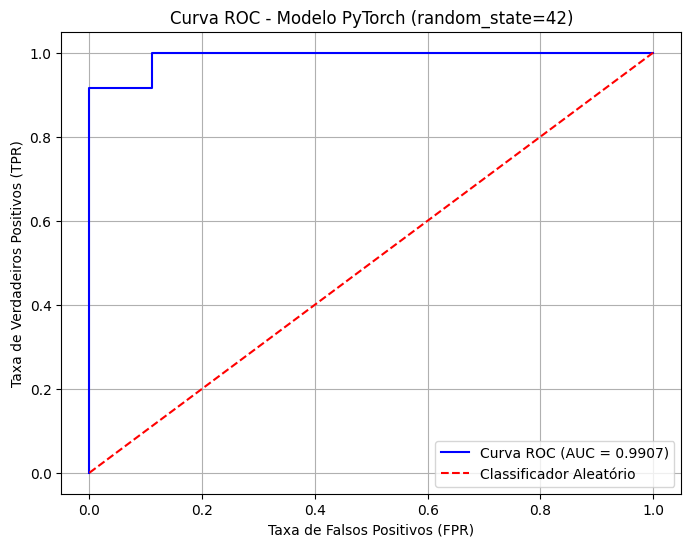

AUC Score: 0.9907


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_probs_np)
auc_score = roc_auc_score(y_test_np, y_pred_probs_np)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificador Aleatório')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Modelo PyTorch (random_state=42)')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score: {auc_score:.4f}")